Extracting features using Angle-Based Symmetry Index...
Training ST-GCN on 102 samples...
Epoch 5 | T-Loss: 0.676 | V-Loss: 0.696 | T-Acc: 57.84% | V-Acc: 54.55%
Epoch 10 | T-Loss: 0.667 | V-Loss: 0.693 | T-Acc: 63.73% | V-Acc: 54.55%
Epoch 15 | T-Loss: 0.669 | V-Loss: 0.666 | T-Acc: 58.82% | V-Acc: 54.55%
Epoch 20 | T-Loss: 0.657 | V-Loss: 0.666 | T-Acc: 65.69% | V-Acc: 54.55%
Epoch 25 | T-Loss: 0.634 | V-Loss: 0.646 | T-Acc: 69.61% | V-Acc: 59.09%
Epoch 30 | T-Loss: 0.640 | V-Loss: 0.626 | T-Acc: 68.63% | V-Acc: 81.82%
Epoch 35 | T-Loss: 0.609 | V-Loss: 0.602 | T-Acc: 75.49% | V-Acc: 90.91%
Epoch 40 | T-Loss: 0.596 | V-Loss: 0.588 | T-Acc: 77.45% | V-Acc: 90.91%
Epoch 45 | T-Loss: 0.591 | V-Loss: 0.588 | T-Acc: 78.43% | V-Acc: 90.91%
Early stopping triggered.

Final Test Accuracy: 86.36%
              precision    recall  f1-score   support

        Good       1.00      0.70      0.82        10
         Bad       0.80      1.00      0.89        12

    accuracy                       

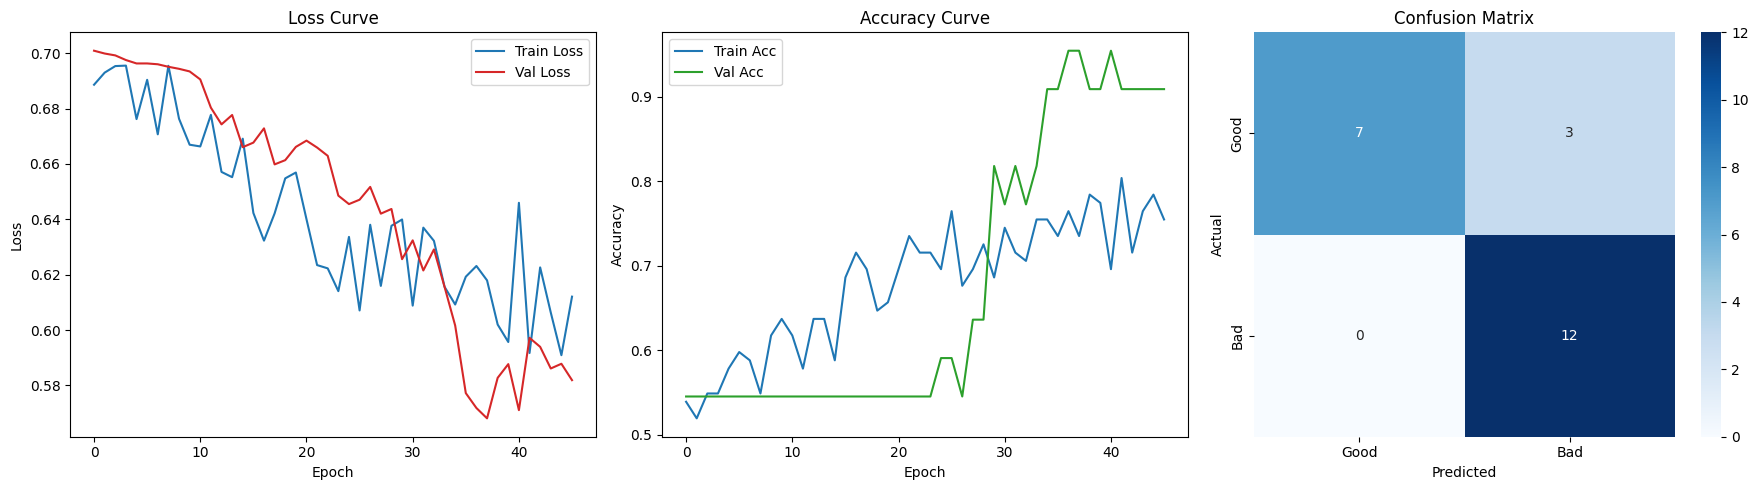


Metrics saved to: C:\Users\PRASHANTH\Downloads\squat_model_metrics.xlsx


In [8]:
################################################ ST-GCN ##########################################################

import cv2
import mediapipe as mp
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import Adam
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
import os
import glob
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# ============================================================================
# CONFIG
# ============================================================================
VIDEO_DIR = r"C:\\Users\\PRASHANTH\\gcn"
SEQ_LEN = 30
BATCH_SIZE = 16
EPOCHS = 100 
LEARNING_RATE = 3e-4 
WEIGHT_DECAY = 5e-2 

ADJ = [
    (0,1),(0,2),(1,3),(2,4), (5,6),(5,7),(7,9),(6,8),(8,10),
    (11,12),(11,13),(13,15),(12,14),(14,16), (5,11),(6,12)
]

def get_adj_matrix():
    A = np.eye(17)
    for i, j in ADJ:
        A[i, j] = A[j, i] = 1
    D = np.diag(np.sum(A, axis=1)**-0.5)
    A_norm = D @ A @ D
    return torch.FloatTensor(A_norm)

# ============================================================================
# SQUAT PROCESSOR & UTILS
# ============================================================================
class SkeletonUtils:
    @staticmethod
    def normalize(coords):
        for i in range(len(coords)):
            mid_hip = (coords[i, 11, :] + coords[i, 12, :]) / 2
            coords[i] -= mid_hip
        return coords

    @staticmethod
    def add_noise(x, sigma=0.02):
        noise = torch.randn_like(x) * sigma
        return x + noise

class SquatProcessor:
    def __init__(self):
        self.pose = mp.solutions.pose.Pose(
            static_image_mode=False, 
            model_complexity=2, 
            min_detection_confidence=0.5
        )
    
    def calculate_3d_angle(self, a, b, c):
        a = np.array(a)
        b = np.array(b)
        c = np.array(c)
        ba = a - b
        bc = c - b
        cosine_angle = np.dot(ba, bc) / (np.linalg.norm(ba) * np.linalg.norm(bc) + 1e-6)
        angle = np.arccos(np.clip(cosine_angle, -1.0, 1.0))
        return np.degrees(angle)

    def get_si(self, l_val, r_val):
        return ((l_val - r_val) / (0.5 * (l_val + r_val) + 1e-6)) * 100

    def process_video(self, path):
        cap = cv2.VideoCapture(path)
        coords, labels = [], []
        while cap.isOpened():
            ret, frame = cap.read()
            if not ret: break
            img = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            res = self.pose.process(img)
            
            if res.pose_world_landmarks:
                lm = res.pose_world_landmarks.landmark
                l_angle = self.calculate_3d_angle([lm[23].x, lm[23].y, lm[23].z], 
                                                 [lm[25].x, lm[25].y, lm[25].z], 
                                                 [lm[27].x, lm[27].y, lm[27].z])
                
                r_angle = self.calculate_3d_angle([lm[24].x, lm[24].y, lm[24].z], 
                                                 [lm[26].x, lm[26].y, lm[26].z], 
                                                 [lm[28].x, lm[28].y, lm[28].z])
                
                pts = [[lm[i].x, lm[i].y, lm[i].z] for i in range(12, 29)]
                coords.append(pts)
                si = self.get_si(l_angle, r_angle)
                labels.append(1 if si > 10 else 0)

        cap.release()
        if len(coords) < SEQ_LEN: return None, None
        
        coords = SkeletonUtils.normalize(np.array(coords))
        final_label = 1 if np.mean(labels) > 0.4 else 0
        return coords, final_label

# ============================================================================
# ST-GCN LAYER
# ============================================================================
class ST_GCN_Layer(nn.Module):
    def __init__(self, in_c, out_c, adj, stride=1):
        super().__init__()
        self.adj = nn.Parameter(adj, requires_grad=False)
        self.gcn = nn.Conv2d(in_c, out_c, kernel_size=1)
        self.tcn = nn.Sequential(
            nn.BatchNorm2d(out_c),
            nn.ReLU(inplace=True),
            nn.Dropout2d(0.4),
            nn.Conv2d(out_c, out_c, (9, 1), (stride, 1), (4, 0)),
            nn.BatchNorm2d(out_c),
            nn.Dropout2d(0.3)
        )
        self.residual = nn.Conv2d(in_c, out_c, 1) if in_c != out_c else nn.Identity()

    def forward(self, x):
        res = self.residual(x)
        x = torch.einsum('nctv,vw->nctw', x, self.adj)
        x = self.gcn(x)
        x = self.tcn(x) + 0.6 * res
        return torch.relu(x)

# ============================================================================
# ST-GCN MODEL
# ============================================================================
class STGCN(nn.Module):
    def __init__(self):
        super().__init__()
        adj = get_adj_matrix()
        
        self.layer1 = ST_GCN_Layer(3, 20, adj)
        self.layer2 = ST_GCN_Layer(20, 24, adj)
        self.layer3 = ST_GCN_Layer(24, 20, adj)
        
        self.pool = nn.AdaptiveAvgPool2d(1)
        
        self.fc = nn.Sequential(
            nn.Dropout(0.4),
            nn.Linear(20, 8),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(8, 2)
        )

    def forward(self, x):
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.pool(x).view(x.size(0), -1)
        return self.fc(x)

# ============================================================================
# CLEAN EVALUATION
# ============================================================================
def evaluate(model, loader, device, criterion=None):
    model.eval()
    all_preds, all_labels = [], []
    total_loss = 0
    
    with torch.no_grad():
        for data, target in loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            
            if criterion:
                total_loss += criterion(output, target).item()
            
            all_preds.extend(torch.argmax(output, 1).cpu().numpy())
            all_labels.extend(target.cpu().numpy())
    
    return accuracy_score(all_labels, all_preds), total_loss/len(loader), all_labels, all_preds

# ============================================================================
# MAIN EXECUTION
# ============================================================================
def main():
    proc = SquatProcessor()
    videos = glob.glob(os.path.join(VIDEO_DIR, "*.mp4"))
    X, y = [], []
    
    print("Extracting features using Angle-Based Symmetry Index...")
    for v in videos:
        coords, label = proc.process_video(v)
        if coords is not None:
            for i in range(0, len(coords) - SEQ_LEN, 10): 
                X.append(coords[i:i+SEQ_LEN].transpose(2, 0, 1))
                y.append(label)

    if not X: 
        print("No valid data found.")
        return

    X = torch.FloatTensor(np.array(X))
    y = torch.LongTensor(np.array(y))
    
    X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
    X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)
    
    train_loader = DataLoader(list(zip(X_train, y_train)), BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(list(zip(X_val, y_val)), BATCH_SIZE)
    test_loader = DataLoader(list(zip(X_test, y_test)), BATCH_SIZE)
    
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = STGCN().to(device)
    
    optimizer = Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    criterion = nn.CrossEntropyLoss(label_smoothing=0.2)
    
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    best_val_loss = float('inf')
    patience = 8
    trigger = 0

    print(f"Training ST-GCN on {len(X_train)} samples...")
    for epoch in range(EPOCHS):
        model.train()
        train_loss = 0
        train_preds, train_targets = [], []
        
        for data, target in train_loader:
            data = SkeletonUtils.add_noise(data)
            if torch.rand(1) > 0.5:
                data[:, :, 0] *= -1
            
            data, target = data.to(device), target.to(device)
            optimizer.zero_grad()
            output = model(data)
            loss = criterion(output, target)
            loss.backward()
            
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            
            train_loss += loss.item()
            train_preds.extend(torch.argmax(output, 1).cpu().numpy())
            train_targets.extend(target.cpu().numpy())
        
        train_acc = accuracy_score(train_targets, train_preds)
        val_acc, val_loss, _, _ = evaluate(model, val_loader, device, criterion)
        
        history['train_loss'].append(train_loss/len(train_loader))
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)
        
        if (epoch+1) % 5 == 0:
            print(f"Epoch {epoch+1} | T-Loss: {history['train_loss'][-1]:.3f} | "
                  f"V-Loss: {val_loss:.3f} | T-Acc: {train_acc:.2%} | V-Acc: {val_acc:.2%}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), "squat_stgcn.pt")
            trigger = 0
        else:
            trigger += 1
            if trigger >= patience:
                print("Early stopping triggered.")
                break

    model.load_state_dict(torch.load("squat_stgcn.pt"))
    test_acc, _, y_true, y_pred = evaluate(model, test_loader, device)
    cm = confusion_matrix(y_true, y_pred)

    print(f"\nFinal Test Accuracy: {test_acc:.2%}")
    print(classification_report(y_true, y_pred, target_names=['Good', 'Bad']))

    # ============================================================================
    # PLOTTING
    # ============================================================================
    plt.figure(figsize=(18, 5))

    plt.subplot(1, 3, 1)
    plt.plot(history['train_loss'], label='Train Loss', color='tab:blue')
    plt.plot(history['val_loss'], label='Val Loss', color='tab:red')
    plt.title('Loss Curve')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.subplot(1, 3, 2)
    plt.plot(history['train_acc'], label='Train Acc', color='tab:blue')
    plt.plot(history['val_acc'], label='Val Acc', color='tab:green')
    plt.title('Accuracy Curve')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.subplot(1, 3, 3)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Good', 'Bad'], yticklabels=['Good', 'Bad'])
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')

    plt.tight_layout()
    plt.show()

    # ============================================================================
    # EXCEL EXPORT
    # ============================================================================
    df_history = pd.DataFrame(history)
    df_cm = pd.DataFrame(cm, index=['Good', 'Bad'], columns=['Good', 'Bad'])
    
    downloads_path = os.path.join(os.path.expanduser("~"), "Downloads")
    excel_file = os.path.join(downloads_path, "squat_model_metrics.xlsx")
    
    with pd.ExcelWriter(excel_file) as writer:
        df_history.to_excel(writer, sheet_name='Training_History', index_label='Epoch')
        df_cm.to_excel(writer, sheet_name='Confusion_Matrix')
    
    print(f"\nMetrics saved to: {excel_file}")

if __name__ == "__main__":
    main()
